In [1]:
import pandas as pd

df = pd.read_csv("data_combined.csv", delimiter=',')
df.head()

,File_ID,Group_ID,Razvan,Boris,Joost,Jan
0,img_0393.png,4,1,0,1,1
1,img_0394.png,4,1,2,2,1
2,img_0395.png,4,1,0,0,1
3,img_0396.png,4,0,0,0,0
4,img_0397.png,4,1,1,1,1


In [2]:
import numpy as np
# Calculate Kappa score with sklearn
from sklearn.metrics import cohen_kappa_score

annotators = [
    "Razvan",
    "Boris",
    "Joost",
    "Jan"
]

agreement_matrix = np.zeros((4, 4))

for i in range(4):
    for j in range(4):
        
        ann1 = df[annotators[i]]
        ann2 = df[annotators[j]]
        
        valid = ann1.notna() & ann2.notna()
        ann1_clean = ann1[valid]
        ann2_clean = ann2[valid]
        
        kappa = cohen_kappa_score(ann1_clean, ann2_clean)
        
        agreement_matrix[i, j] = kappa

agreement_df = pd.DataFrame(np.round(agreement_matrix, 4), index=annotators, columns=annotators)

# Display as styled table
agreement_df.style.background_gradient(cmap="Blues", vmin=0, vmax=1).format("{:.4f}")

,Razvan,Boris,Joost,Jan
Razvan,1.0000,0.4834,0.5837,0.5801
Boris,0.4834,1.0000,0.6807,0.2581
Joost,0.5837,0.6807,1.0000,0.3315
Jan,0.5801,0.2581,0.3315,1.0000


In [3]:
""" 
The agreements range from 0.26 to 0.68, with an average agreement of around 0.5 which suggests a moderate agreement.
 
 Most annotator pairs are close to this average agreement except for the pair of annotator 1 and annotator 2 and the pair of annotator 1 and annotator 3, as the agreement there is a lot lower than the average, this could be because annotators may have had a different definition of no, some and a lot of hair. However, without looking a lot of samples and discussion them in the group it is not possible to formulate the actual reason for this.

Overall, our group achieved a moderate agreement, which is acceptable but can be improved.
"""

' \nThe agreements range from 0.26 to 0.68, with an average agreement of around 0.5 which suggests a moderate agreement.\n\n Most annotator pairs are close to this average agreement except for the pair of annotator 1 and annotator 2 and the pair of annotator 1 and annotator 3, as the agreement there is a lot lower than the average, this could be because annotators may have had a different definition of no, some and a lot of hair. However, without looking a lot of samples and discussion them in the group it is not possible to formulate the actual reason for this.\n\nOverall, our group achieved a moderate agreement, which is acceptable but can be improved.\n'

In [4]:
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

ratings = df[["Razvan", "Boris", "Joost", "Jan"]].values
agg_data, categories = aggregate_raters(ratings)

# Calculate Fleiss' Kappa
fk = fleiss_kappa(agg_data, method='fleiss')

print(f"Fleiss' Kappa (all 4 annotators): {fk:.4f}")

Fleiss' Kappa (all 4 annotators): 0.4561


In [5]:
# Calculate std across raters for each image (higher = more disagreement)
rating_cols = ["Razvan", "Boris", "Joost", "Jan"]
df["rating_std"] = df[rating_cols].std(axis=1)

disagreement_df = df.sort_values("rating_std", ascending=False)

In [6]:
# Top disagreement images
print("Top 10 images with HIGHEST disagreement:\n")
top_10 = disagreement_df[["File_ID"] + rating_cols + ["rating_std"]].head(10).copy()
top_10 = top_10.reset_index(drop=True)
top_10.index = top_10.index + 1
top_10 = top_10.rename(columns={"rating_std": "Standard Deviation"})
top_10 = top_10.round(2)
display(top_10.style.background_gradient(subset=["Standard Deviation"], cmap="Reds"))

Top 10 images with HIGHEST disagreement:



,File_ID,Razvan,Boris,Joost,Jan,Standard Deviation
1,img_0440.png,1,2,0,1,0.820000
2,img_0394.png,1,2,2,1,0.580000
3,img_0400.png,1,0,0,1,0.580000
4,img_0395.png,1,0,0,1,0.580000
5,img_0407.png,1,2,2,1,0.580000
6,img_0410.png,1,2,2,1,0.580000
7,img_0401.png,1,2,1,2,0.580000
8,img_0426.png,1,0,0,1,0.580000
9,img_0452.png,1,0,0,1,0.580000
10,img_0464.png,1,2,2,1,0.580000


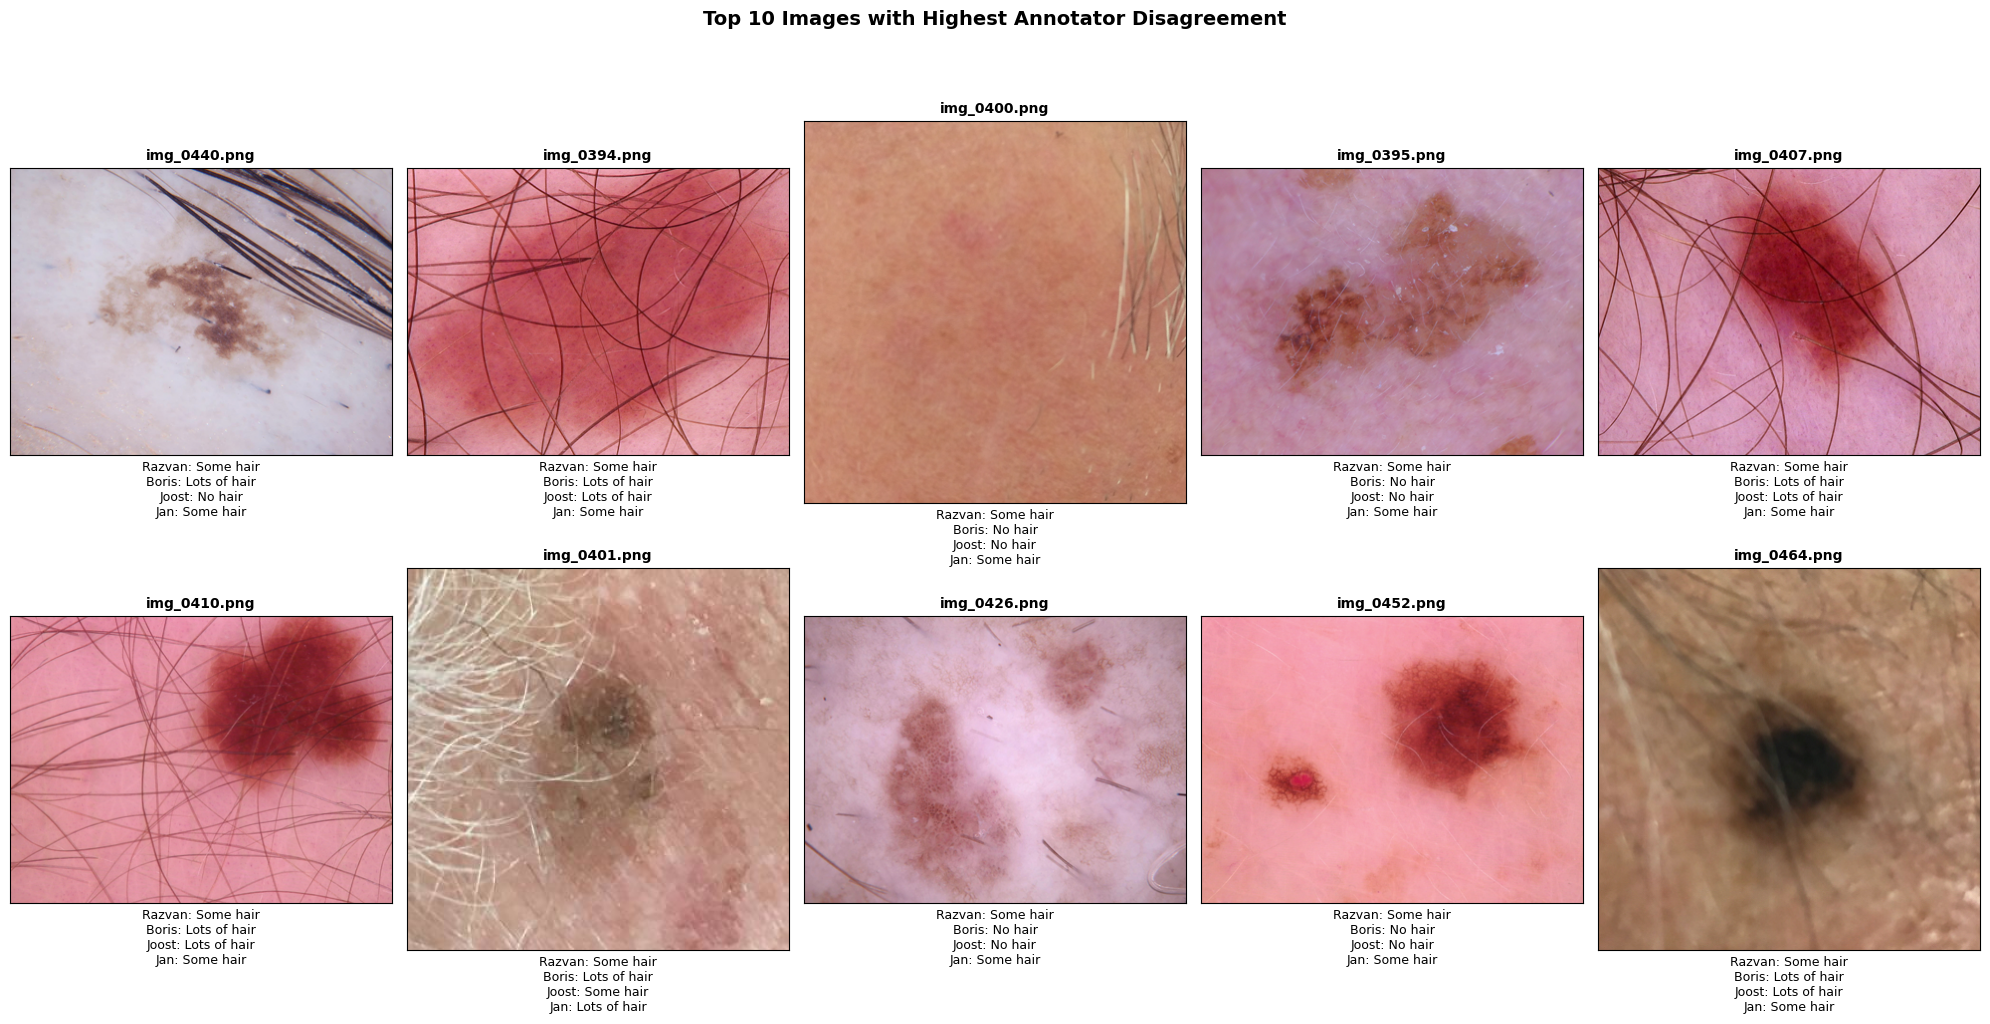

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

top_10_files = disagreement_df["File_ID"].head(10).tolist()
images_dir = "C:\\Users\\ADMIN\\Desktop\\FontysStuff\\ADAI-individual-repository-2025\\Resources\\data"
label_map = {0: "No hair", 1: "Some hair", 2: "Lots of hair"}

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (ax, file_id) in enumerate(zip(axes, top_10_files)):
    img_path = os.path.join(images_dir, file_id)
    
    # Get annotations for this image
    row = disagreement_df[disagreement_df["File_ID"] == file_id].iloc[0]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    
    annotations = f"Razvan: {label_map.get(int(row['Razvan']), row['Razvan'])}\n"
    annotations += f"Boris: {label_map.get(int(row['Boris']), row['Boris'])}\n"
    annotations += f"Joost: {label_map.get(int(row['Joost']), row['Joost'])}\n"
    annotations += f"Jan: {label_map.get(int(row['Jan']), row['Jan'])}"
    
    ax.set_title(f"{file_id}", fontsize=10, fontweight='bold')
    ax.set_xlabel(annotations, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Top 10 Images with Highest Annotator Disagreement", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()